
Assignment: Executive Hotel Booking EDA Report (Day 15)

Using the provided large hotel booking dataset (found in the "Study Material" tab of the LMS), perform a complete end-to-end Exploratory Data Analysis (EDA) and prepare an executive-ready EDA report. Apply the data science workflow learned throughout the program by first understanding the dataset and assessing its data quality, including missing values, duplicate records, incorrect data types, inconsistent values, and outliers, then clean and preprocess the data appropriately before carrying out univariate and bivariate analysis, descriptive statistics, group-wise analysis, correlation analysis, and data visualization. Use suitable Matplotlib and Seaborn visualizations to uncover important trends, patterns, and relationships, and present 3 to 5 key business insights supported by your analysis. Finally, translate your findings into 5 to 7 practical recommendations or decision-making points for management, and present the complete analysis in a professional Jupyter/Google Colab notebook and executive-ready EDA report.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
data = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
data

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25175,HTL022936,City Hotel,Dubai,2024-06-08,2024-12-30,205,3,3,2,0.0,...,HB,6,101.51,0,1,4.06,Canceled,1,2025-01-04,609.08
25176,HTL008794,Resort Hotel,Bali,2025-09-30,2026-09-30,365,1,0,2,1.0,...,BB,1,171.53,0,2,4.69,Canceled,1,2026-09-30,171.53
25177,HTL005715,City Hotel,London,2025-12-30,2026-01-28,29,3,1,1,0.0,...,Undefined,4,125.10,1,0,3.79,Check-Out,0,2026-01-29,500.40
25178,HTL020611,City Hotel,Lisbon,2024-07-17,2024-12-12,148,0,2,3,0.0,...,FB,2,108.29,2,1,3.93,Canceled,1,2024-12-12,216.58


## 1. Data Understanding



In [4]:
data.shape

(25180, 35)

In [5]:
data.dtypes

Booking_ID                      object
Hotel_Type                      object
Hotel_Location                  object
Booking_Date                    object
Arrival_Date                    object
Lead_Time_Days                   int64
Weekend_Nights                   int64
Weekday_Nights                   int64
Adults                           int64
Children                       float64
Babies                           int64
Country                         object
Market_Segment                  object
Distribution_Channel            object
Is_Repeated_Guest                int64
Previous_Cancellations           int64
Previous_Bookings                int64
Room_Type_Reserved              object
Room_Type_Assigned              object
Booking_Changes                  int64
Deposit_Type                    object
Agent_ID                       float64
Company_ID                     float64
Days_In_Waiting_List             int64
Customer_Type                   object
Meal_Type                

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Lead_Time_Days,25180.0,182.200556,105.604452,0.00,91.00,182.000,273.0000,920.00
Weekend_Nights,25180.0,1.240429,1.063802,0.00,0.00,1.000,2.0000,3.00
Weekday_Nights,25180.0,2.451072,2.031003,0.00,1.00,2.000,4.0000,13.00
Adults,25180.0,2.198967,0.662379,1.00,2.00,2.000,2.0000,7.00
Children,25059.0,0.372122,0.657811,0.00,0.00,0.000,1.0000,6.00
Babies,25180.0,0.043050,0.225057,0.00,0.00,0.000,0.0000,2.00
Is_Repeated_Guest,25180.0,0.172597,0.377906,0.00,0.00,0.000,0.0000,1.00
Previous_Cancellations,25180.0,0.038642,0.251403,0.00,0.00,0.000,0.0000,3.00
Previous_Bookings,25180.0,1.117037,2.829046,0.00,0.00,0.000,0.0000,12.00
Booking_Changes,25180.0,0.601191,0.894293,0.00,0.00,0.000,1.0000,4.00


## 2. Data Quality Assessment



In [8]:
data.isnull().sum()

Booking_ID                         0
Hotel_Type                         0
Hotel_Location                   106
Booking_Date                       0
Arrival_Date                       0
Lead_Time_Days                     0
Weekend_Nights                     0
Weekday_Nights                     0
Adults                             0
Children                         121
Babies                             0
Country                          466
Market_Segment                     0
Distribution_Channel               0
Is_Repeated_Guest                  0
Previous_Cancellations             0
Previous_Bookings                  0
Room_Type_Reserved                 0
Room_Type_Assigned                 0
Booking_Changes                    0
Deposit_Type                       0
Agent_ID                         304
Company_ID                     20729
Days_In_Waiting_List               0
Customer_Type                      0
Meal_Type                        245
Total_Nights                       0
A

In [9]:
data.duplicated().sum()

np.int64(180)

In [10]:
hotel_all_types = data["Hotel_Type"].value_counts()
hotel_all_types

Hotel_Type
City Hotel      15606
Resort Hotel     9454
CITY HOTEL         44
city hotel         43
City hotel         33
Name: count, dtype: int64

In [11]:
all_meal_type = data["Meal_Type"].value_counts()
all_meal_type

Meal_Type
BB           5027
Undefined    4978
SC           4945
HB           4939
FB           4939
BB             38
bb             32
 B&B           30
Unknown         7
Name: count, dtype: int64

In [12]:
Market_Segments_type = data["Market_Segment"].value_counts()
Market_Segments_type

Market_Segment
Online TA        10782
Offline TA/TO     5483
Direct            3827
Corporate         3012
Groups            1924
ONLINE TA           53
online ta           51
Online TA           48
Name: count, dtype: int64

In [13]:
fake_review = data[data["Satisfaction_Score"] > 5]

print("Impossible satisfaction rows (>5):", len(fake_review))
print("Max satisfaction value:", data["Satisfaction_Score"].max())
fake_review[["Booking_ID", "Satisfaction_Score"]]


Impossible satisfaction rows (>5): 1
Max satisfaction value: 5.9


,Booking_ID,Satisfaction_Score
17445,HTL019885,5.9


In [14]:
q1 = data["ADR"].quantile(0.25)
q3 = data["ADR"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = data[(data["ADR"] < lower) | (data["ADR"] > upper)]
print("Number of outliers:", len(outliers))
print("Upper limit:", round(upper, 2))
print("Max ADR:", data["ADR"].max())

Number of outliers: 359
Upper limit: 264.31
Max ADR: 710.5


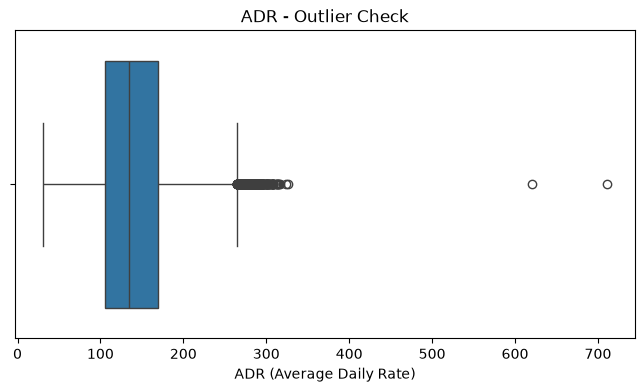

Median ADR: 134.43
Maximum ADR: 710.5


In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=data["ADR"])
plt.title("ADR - Outlier Check")
plt.xlabel("ADR (Average Daily Rate)")
plt.show()

print("Median ADR:", round(data["ADR"].median(), 2))
print("Maximum ADR:", data["ADR"].max())


In [16]:
longest_lead_time = data["Lead_Time_Days"].max()
print("Longest lead time:", longest_lead_time, "days")

data.nlargest(5, "Lead_Time_Days")[["Booking_ID", "Lead_Time_Days", "Arrival_Date"]]

Longest lead time: 920 days


,Booking_ID,Lead_Time_Days,Arrival_Date
6729,HTL000812,920,2025-04-01
16730,HTL000251,850,2024-10-21
54,HTL019546,365,2026-03-06
314,HTL020734,365,2026-04-13
485,HTL016467,365,2026-07-20


## 3. Data Cleaning & Preprocessing



In [17]:
data = data.drop_duplicates()
data

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25175,HTL022936,City Hotel,Dubai,2024-06-08,2024-12-30,205,3,3,2,0.0,...,HB,6,101.51,0,1,4.06,Canceled,1,2025-01-04,609.08
25176,HTL008794,Resort Hotel,Bali,2025-09-30,2026-09-30,365,1,0,2,1.0,...,BB,1,171.53,0,2,4.69,Canceled,1,2026-09-30,171.53
25177,HTL005715,City Hotel,London,2025-12-30,2026-01-28,29,3,1,1,0.0,...,Undefined,4,125.10,1,0,3.79,Check-Out,0,2026-01-29,500.40
25178,HTL020611,City Hotel,Lisbon,2024-07-17,2024-12-12,148,0,2,3,0.0,...,FB,2,108.29,2,1,3.93,Canceled,1,2024-12-12,216.58


In [18]:
print("Rows after dropping duplicates:", data.shape)

Rows after dropping duplicates: (25000, 35)


In [19]:
data["Hotel_Type"] = data["Hotel_Type"].str.strip().str.title()
data["Hotel_Type"]

C:\Users\harshil patel\AppData\Local\Temp\ipykernel_1532\2797209646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Hotel_Type"] = data["Hotel_Type"].str.strip().str.title()


0          City Hotel
1          City Hotel
2          City Hotel
3          City Hotel
4          City Hotel
             ...     
25175      City Hotel
25176    Resort Hotel
25177      City Hotel
25178      City Hotel
25179    Resort Hotel
Name: Hotel_Type, Length: 25000, dtype: object

In [20]:
data["Market_Segment"] = data["Market_Segment"].str.strip().str.title()
data["Market_Segment"]


C:\Users\harshil patel\AppData\Local\Temp\ipykernel_1532\1485984118.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Market_Segment"] = data["Market_Segment"].str.strip().str.title()


0               Direct
1               Groups
2            Online Ta
3        Offline Ta/To
4               Direct
             ...      
25175    Offline Ta/To
25176        Online Ta
25177    Offline Ta/To
25178        Online Ta
25179        Online Ta
Name: Market_Segment, Length: 25000, dtype: object

In [21]:

data["Meal_Type"] = data["Meal_Type"].str.strip().str.upper()
data["Meal_Type"] = data["Meal_Type"].replace({"B&B": "BB", "UNDEFINED": "OTHER", "UNKNOWN": "OTHER"})
print(data["Meal_Type"].value_counts())

Meal_Type
BB       5102
OTHER    4950
FB       4910
SC       4906
HB       4893
Name: count, dtype: int64


C:\Users\harshil patel\AppData\Local\Temp\ipykernel_1532\1239358260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Meal_Type"] = data["Meal_Type"].str.strip().str.upper()
C:\Users\harshil patel\AppData\Local\Temp\ipykernel_1532\1239358260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Meal_Type"] = data["Meal_Type"].replace({"B&B": "BB", "UNDEFINED": "OTHER", "UNKNOWN": "OTHER"})


In [22]:

if "Company_ID" in data.columns:
    data = data.drop(columns=["Company_ID"])


data["Country"] = data["Country"].fillna("Unknown")
data["Agent_ID"] = data["Agent_ID"].fillna(0)
data["Meal_Type"] = data["Meal_Type"].fillna("OTHER")


data["Children"] = data["Children"].fillna(data["Children"].median())
data["Satisfaction_Score"] = data["Satisfaction_Score"].fillna(data["Satisfaction_Score"].median())
data["ADR"] = data["ADR"].fillna(data["ADR"].median())

print(data.isnull().sum())

Booking_ID                       0
Hotel_Type                       0
Hotel_Location                 105
Booking_Date                     0
Arrival_Date                     0
Lead_Time_Days                   0
Weekend_Nights                   0
Weekday_Nights                   0
Adults                           0
Children                         0
Babies                           0
Country                          0
Market_Segment                   0
Distribution_Channel             0
Is_Repeated_Guest                0
Previous_Cancellations           0
Previous_Bookings                0
Room_Type_Reserved               0
Room_Type_Assigned               0
Booking_Changes                  0
Deposit_Type                     0
Agent_ID                         0
Days_In_Waiting_List             0
Customer_Type                    0
Meal_Type                        0
Total_Nights                     0
ADR                              0
Required_Car_Parking_Spaces      0
Total_Special_Reques

In [23]:

data["Booking_Date"] = pd.to_datetime(data["Booking_Date"])
data["Arrival_Date"] = pd.to_datetime(data["Arrival_Date"])
data["Reservation_Status_Date"] = pd.to_datetime(data["Reservation_Status_Date"])


data["Arrival_Month"] = data["Arrival_Date"].dt.month

data["Lead_Time_Bin"] = pd.cut(data["Lead_Time_Days"],
                               bins=[0, 30, 90, 180, 1000],
                               labels=["0-30 days", "31-90 days", "91-180 days", "180+ days"])

print(data[["Arrival_Month", "Lead_Time_Bin"]].head())

   Arrival_Month Lead_Time_Bin
0              7     180+ days
1              2     180+ days
2              6    31-90 days
3              4     0-30 days
4              5     180+ days


In [24]:

print("Before:", len(data))
data = data[data["Satisfaction_Score"] <= 5]
print("After:", len(data))

print("Final shape:", data.shape)

Before: 25000
After: 24999
Final shape: (24999, 36)


## 4. Univariate Analysis



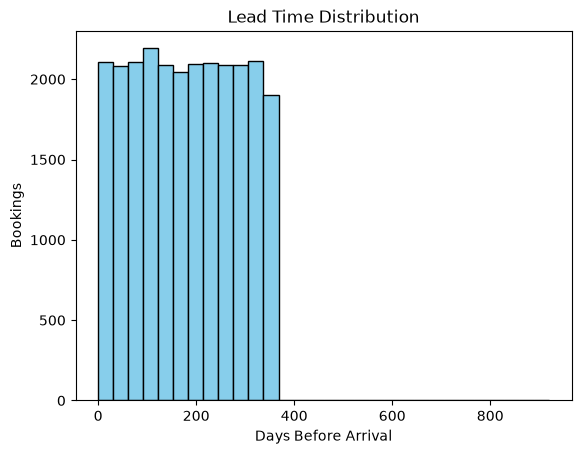

In [25]:


plt.hist(data["Lead_Time_Days"], bins=30, color="skyblue", edgecolor="black")
plt.title("Lead Time Distribution")
plt.xlabel("Days Before Arrival")
plt.ylabel("Bookings")
plt.show()

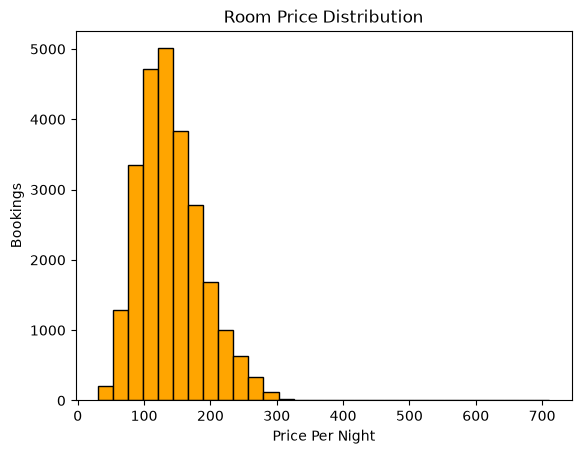

In [26]:
plt.hist(data["ADR"], bins=30, color="orange", edgecolor="black")
plt.title("Room Price Distribution")
plt.xlabel("Price Per Night")
plt.ylabel("Bookings")
plt.show()

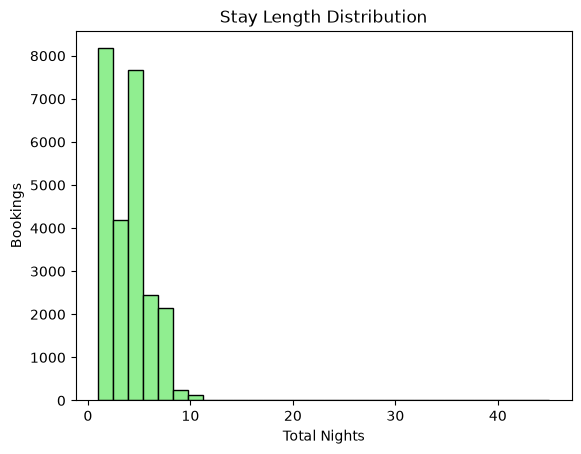

In [ ]:

plt.hist(data["Total_Nights"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Stay Length Distribution")
plt.xlabel("Total Nights")
plt.ylabel("Bookings")
plt.show()

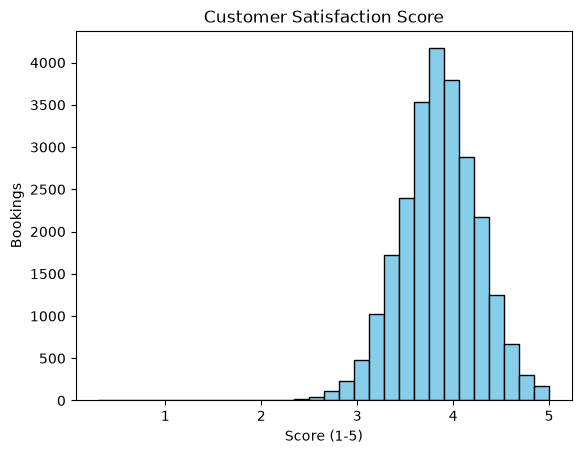

In [28]:


plt.hist(data["Satisfaction_Score"], bins=30, color="skyblue", edgecolor="black")
plt.title("Customer Satisfaction Score")
plt.xlabel("Score (1-5)")
plt.ylabel("Bookings")
plt.show()

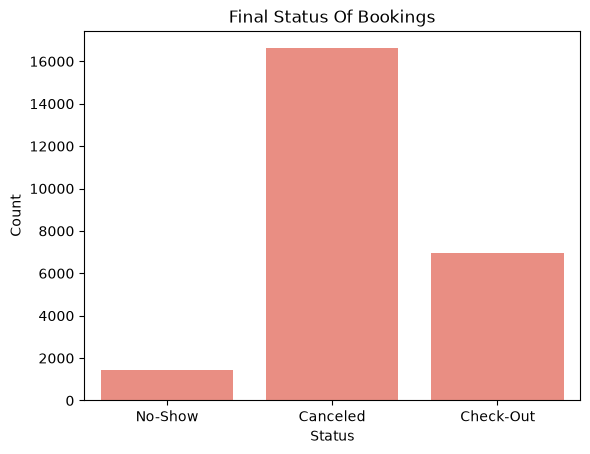

In [29]:

sns.countplot(x="Reservation_Status", data=data, color="salmon")
plt.title("Final Status Of Bookings")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

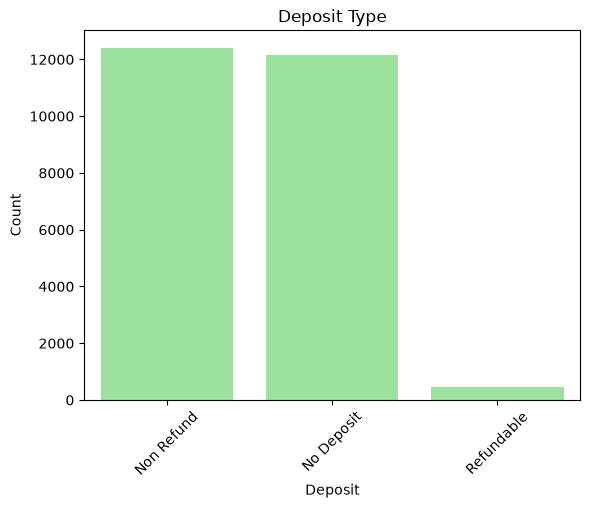

In [30]:

sns.countplot(x="Deposit_Type", data=data, color="lightgreen")
plt.title("Deposit Type")
plt.xlabel("Deposit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

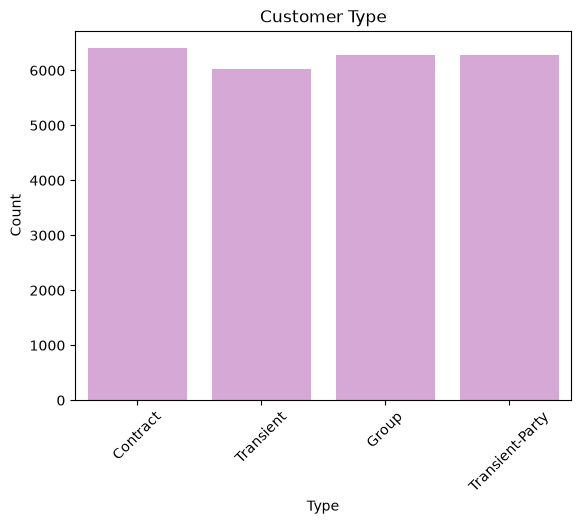

In [31]:
sns.countplot(x="Customer_Type", data=data, color="plum")
plt.title("Customer Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

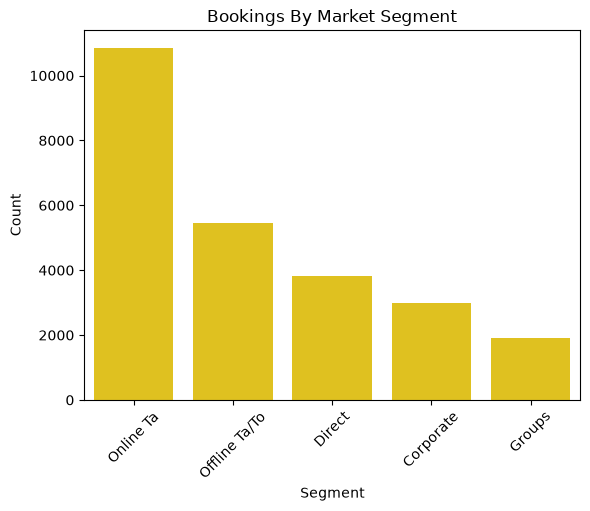

In [32]:

order = data["Market_Segment"].value_counts().index 

sns.countplot(x="Market_Segment", data=data, order=order, color="gold")
plt.title("Bookings By Market Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

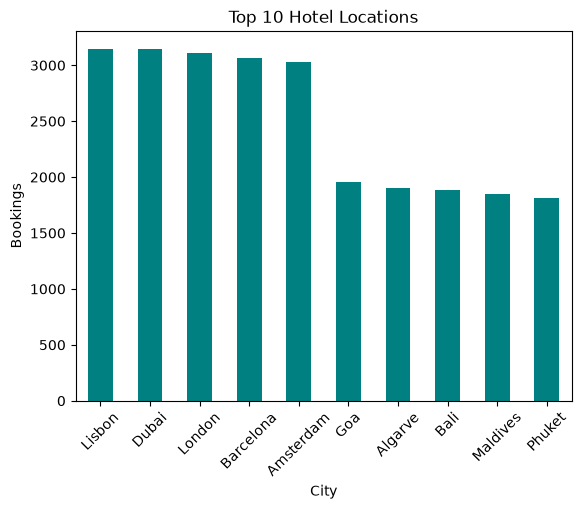

In [34]:

top_10 = data["Hotel_Location"].value_counts().head(10)

top_10.plot(kind="bar", color="teal")
plt.title("Top 10 Hotel Locations")
plt.xlabel("City")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

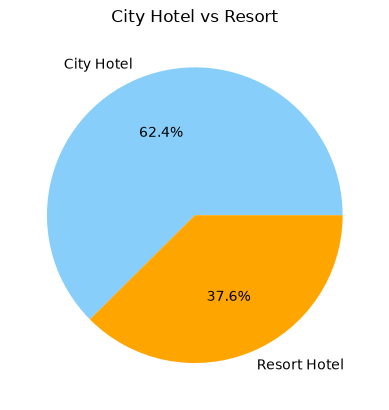

In [35]:
share = data["Hotel_Type"].value_counts()

plt.pie(share, labels=share.index, autopct="%1.1f%%", colors=["lightskyblue", "orange"])
plt.title("City Hotel vs Resort")
plt.show()


## 5. Bivariate & Multivariate Analysis



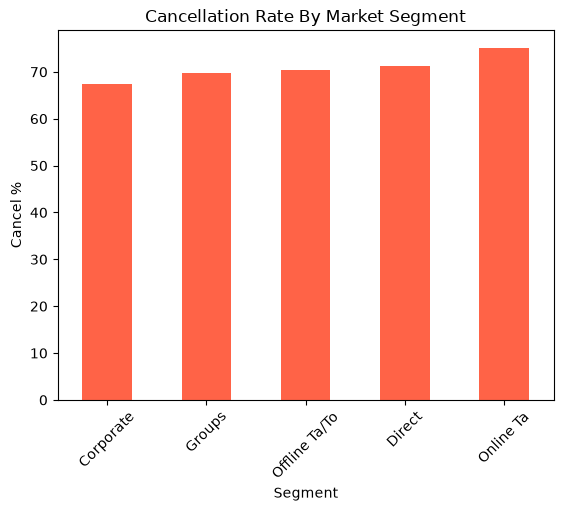

In [36]:

cancel_rate = data.groupby("Market_Segment")["Is_Canceled"].mean() * 100
cancel_rate = cancel_rate.sort_values()

cancel_rate.plot(kind="bar", color="tomato")
plt.title("Cancellation Rate By Market Segment")
plt.xlabel("Segment")
plt.ylabel("Cancel %")
plt.xticks(rotation=45)
plt.show()


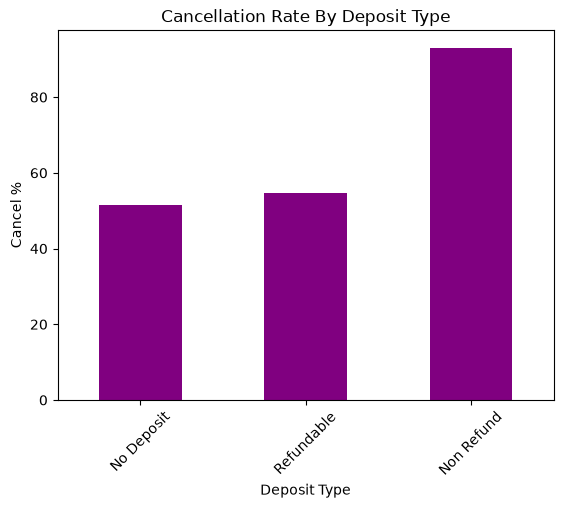

In [37]:

dep_rate = data.groupby("Deposit_Type")["Is_Canceled"].mean() * 100
dep_rate = dep_rate.sort_values()

dep_rate.plot(kind="bar", color="purple")
plt.title("Cancellation Rate By Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancel %")
plt.xticks(rotation=45)
plt.show()

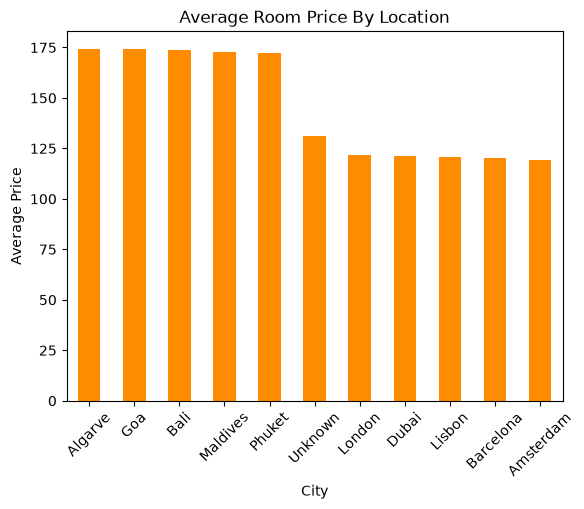

In [38]:
avg_price = data.groupby("Hotel_Location")["ADR"].mean().sort_values(ascending=False)

avg_price.plot(kind="bar", color="darkorange")
plt.title("Average Room Price By Location")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

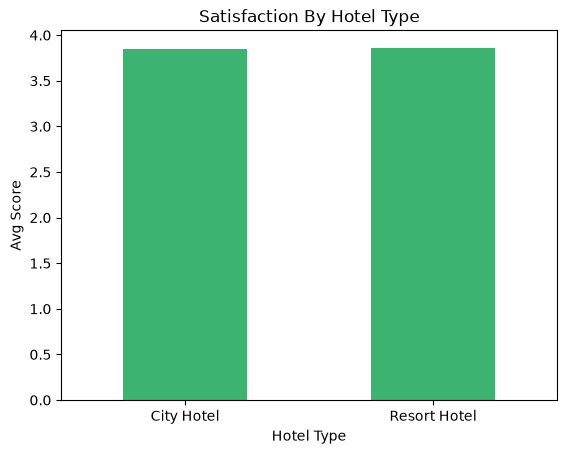

In [39]:
sat_score = data.groupby("Hotel_Type")["Satisfaction_Score"].mean()

sat_score.plot(kind="bar", color="mediumseagreen")
plt.title("Satisfaction By Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Avg Score")
plt.xticks(rotation=0)
plt.show()

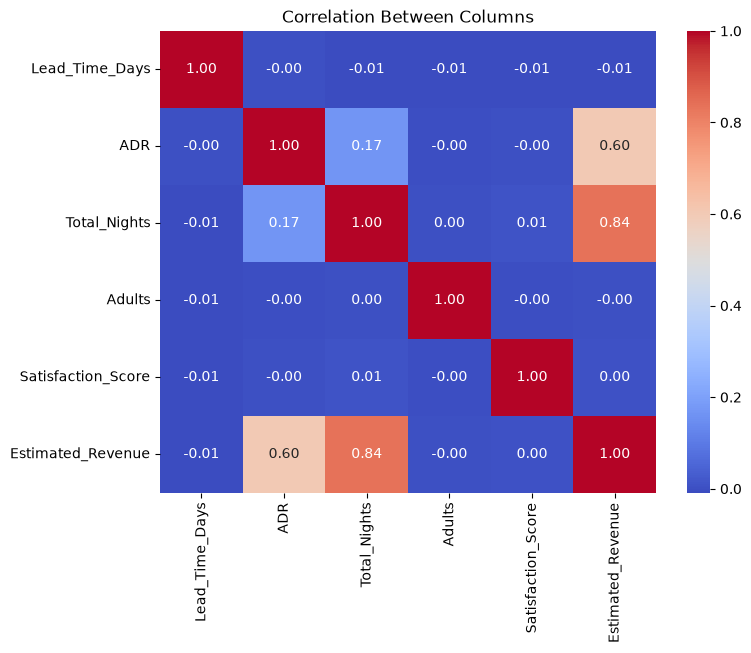

In [41]:

cols = ["Lead_Time_Days", "ADR", "Total_Nights", "Adults",
        "Satisfaction_Score", "Estimated_Revenue"]

corr = data[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Columns")
plt.show()

C:\Users\harshil patel\AppData\Local\Temp\ipykernel_1532\85604312.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_cancel = data.groupby("Lead_Time_Bin")["Is_Canceled"].mean() * 100


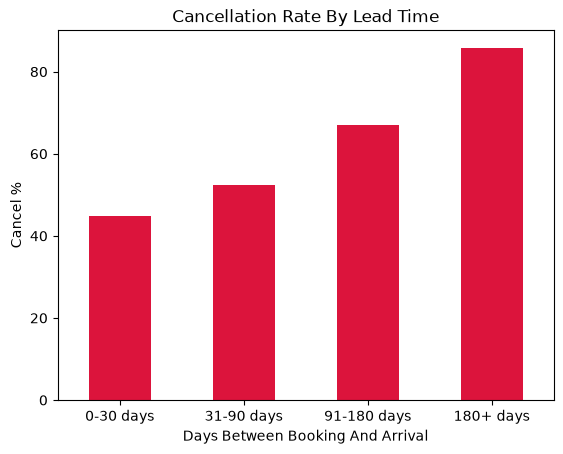

In [42]:

lead_cancel = data.groupby("Lead_Time_Bin")["Is_Canceled"].mean() * 100

lead_cancel.plot(kind="bar", color="crimson")
plt.title("Cancellation Rate By Lead Time")
plt.xlabel("Days Between Booking And Arrival")
plt.ylabel("Cancel %")
plt.xticks(rotation=0)
plt.show()

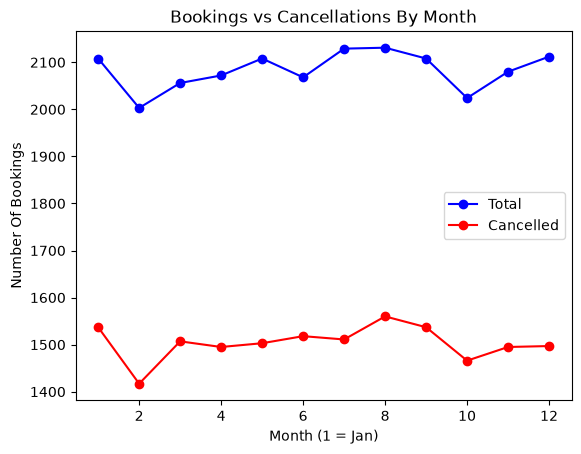

In [43]:

total_bookings = data.groupby("Arrival_Month").size()
cancelled = data[data["Is_Canceled"] == 1].groupby("Arrival_Month").size()

plt.plot(total_bookings.index, total_bookings.values, marker="o", color="blue", label="Total")
plt.plot(cancelled.index, cancelled.values, marker="o", color="red", label="Cancelled")

plt.title("Bookings vs Cancellations By Month")
plt.xlabel("Month (1 = Jan)")
plt.ylabel("Number Of Bookings")
plt.legend()
plt.show()

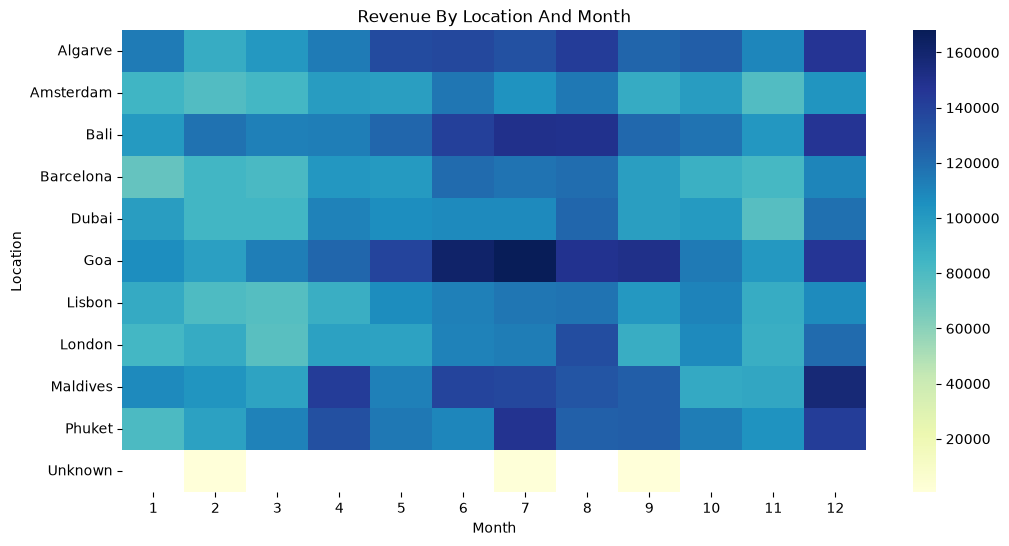

In [44]:

pivot = data.pivot_table(values="Estimated_Revenue",
                         index="Hotel_Location",
                         columns="Arrival_Month",
                         aggfunc="sum")

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Revenue By Location And Month")
plt.xlabel("Month")
plt.ylabel("Location")
plt.show()

## 6. Key Business Insights

1. Cancellation rate is very high (around 72%) - about 7 out of 10 bookings end in cancellation or no-show.
2. Online TA segment brings the most bookings, but cancellations are also high in this segment.
3. Longer lead time means more cancellations - guests who book months early change plans more often.
4. Non-refundable deposits reduce cancellations - the deposit policy actually works.
5. Heavy dependency on online channels is risky - Direct and Corporate segments are weak.

## 7. Recommendations For Management

1. Make confirmation calls or follow an overbooking policy for long lead-time bookings.
2. Review the non-refundable deposit policy carefully - about 93% of such bookings were cancelled.
3. Grow Direct and Corporate bookings to save OTA commission.
4. Use dynamic pricing in peak months to maximize revenue.
5. Investigate locations and room types with low satisfaction scores.
6. Add validation rules in the booking system to stop duplicate entries.
7. Run a quarterly data quality audit to fix errors at the source.